# Análisis breve datos TLS
#### José Delgado Jiménez

In [9]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [10]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

ROOT = Path(".")
RESULTS_DIR = ROOT / "results"

In [11]:
SCENARIOS = {
    "c1_classic": {
        "label": "C1 – X25519, cert clásico",
        "bench_file": "bench_c1_classic.csv",
        "perf_file":  "perf_c1_classic.csv",
    },
    "c2_hybrid_classiccert": {
        "label": "C2 – X25519MLKEM768, cert clásico",
        "bench_file": "bench_c2_hybrid_classiccert.csv",
        "perf_file":  "perf_c2_hybrid_classiccert.csv",
    },
    "c3_classic_pqcert": {
        "label": "C3 – X25519, cert PQC",
        "bench_file": "bench_c3_classic_pqcert.csv",
        "perf_file":  "perf_c3_classic_pqcert.csv",
    },
    "c4_hybrid_pqcert": {
        "label": "C4 – X25519MLKEM768, cert PQC",
        "bench_file": "bench_c4_hybrid_pqcert.csv",
        "perf_file":  "perf_c4_hybrid_pqcert.csv",
    },
}

BASELINE_SCENARIO = "c1_classic"

In [12]:
BENCH_COLUMNS = [
    "run_id",
    "elapsed_ms",
    "success",
    "ssl_error",
    "bytes_read",
    "bytes_written",
]

def load_bench_df(path: Path) -> pd.DataFrame:
    """
    Lee un CSV de bench_* con la cabecera estándar.
    Realiza conversión de tipos mínima.
    """
    if not path.is_file():
        raise FileNotFoundError(f"No se encuentra el fichero: {path}")

    df = pd.read_csv(path)

    missing_cols = [c for c in BENCH_COLUMNS if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Faltan columnas en {path}: {missing_cols}")

    df = df[BENCH_COLUMNS].copy()
    df = df.astype({
        "run_id": int,
        "elapsed_ms": float,
        "success": int,
        "ssl_error": int,
        "bytes_read": int,
        "bytes_written": int,
    })

    return df


def clean_bench_df(df: pd.DataFrame, scenario_name: str) -> pd.DataFrame:
    """
    Aplica sanity checks básicos y filtra a success == 1.
    Devuelve el DataFrame limpio.
    """
    n_total = len(df)
    n_success = df["success"].sum()
    n_fail = n_total - n_success

    print(f"\n{scenario_name}")
    print(f"  Handshakes totales: {n_total}")
    print(f"  Éxitos: {n_success}  |  Fallos: {n_fail}")

    if n_fail > 0:
        print("  [AVISO] Hay handshakes fallidos. Se excluyen del análisis.")
        print(df.loc[df["success"] == 0, "ssl_error"].value_counts())

    if df["bytes_read"].min() <= 0 or df["bytes_written"].min() <= 0:
        print("  [AVISO] bytes_read/bytes_written contienen valores <= 0.")

    sorted_ids = df["run_id"].sort_values().to_numpy()
    diffs = np.diff(sorted_ids)
    if len(sorted_ids) > 1 and not np.all(diffs == 1):
        print("  [AVISO] run_id no es estrictamente consecutivo. Se ignora para el análisis.")

    # Filtrar a success == 1
    clean = df[df["success"] == 1].copy()
    clean.reset_index(drop=True, inplace=True)

    print(f"  Handshakes utilizados en el análisis: {len(clean)}")
    return clean


def compute_latency_stats(df: pd.DataFrame) -> dict:
    """
    Calcula estadísticas de latencia (elapsed_ms) para un escenario.
    Devuelve un dict listo para construir un DataFrame.
    """
    lat = df["elapsed_ms"].astype(float)

    quantiles = lat.quantile([0.50, 0.75, 0.90, 0.95, 0.99])

    return {
        "N": len(lat),
        "mean_ms": lat.mean(),
        "std_ms": lat.std(),
        "min_ms": lat.min(),
        "p50_ms": quantiles.loc[0.50],
        "p75_ms": quantiles.loc[0.75],
        "p90_ms": quantiles.loc[0.90],
        "p95_ms": quantiles.loc[0.95],
        "p99_ms": quantiles.loc[0.99],
        "max_ms": lat.max(),
    }


def compute_handshake_size_stats(df: pd.DataFrame) -> dict:
    """
    Calcula estadísticas básicas de tamaño de handshake (bytes_read / bytes_written).
    """
    br = df["bytes_read"].astype(int)
    bw = df["bytes_written"].astype(int)

    return {
        "bytes_read_mean": br.mean(),
        "bytes_read_std": br.std(),
        "bytes_written_mean": bw.mean(),
        "bytes_written_std": bw.std(),
    }

In [13]:
clean_bench_dfs = {}
latency_stats_dict = {}
size_stats_dict = {}

for key, meta in SCENARIOS.items():
    bench_path = ".." / RESULTS_DIR / meta["bench_file"]
    df_raw = load_bench_df(bench_path)
    df_clean = clean_bench_df(df_raw, key)

    clean_bench_dfs[key] = df_clean
    latency_stats_dict[key] = compute_latency_stats(df_clean)
    size_stats_dict[key] = compute_handshake_size_stats(df_clean)

# DataFrame de latencias
latency_df = pd.DataFrame.from_dict(latency_stats_dict, orient="index")
latency_df.index.name = "scenario"

latency_df["label"] = [SCENARIOS[k]["label"] for k in latency_df.index]

latency_df = latency_df[
    [
        "label",
        "N",
        "mean_ms",
        "std_ms",
        "min_ms",
        "p50_ms",
        "p75_ms",
        "p90_ms",
        "p95_ms",
        "p99_ms",
        "max_ms",
    ]
]


c1_classic
  Handshakes totales: 100000
  Éxitos: 100000  |  Fallos: 0
  Handshakes utilizados en el análisis: 100000

c2_hybrid_classiccert
  Handshakes totales: 100000
  Éxitos: 100000  |  Fallos: 0
  Handshakes utilizados en el análisis: 100000

c3_classic_pqcert
  Handshakes totales: 100000
  Éxitos: 100000  |  Fallos: 0
  Handshakes utilizados en el análisis: 100000

c4_hybrid_pqcert
  Handshakes totales: 100000
  Éxitos: 100000  |  Fallos: 0
  Handshakes utilizados en el análisis: 100000


In [14]:
base_mean = latency_df.loc[BASELINE_SCENARIO, "mean_ms"]
base_p99 = latency_df.loc[BASELINE_SCENARIO, "p99_ms"]

def compute_overhead(col_name: str, base_value: float, df: pd.DataFrame) -> pd.Series:
    return 100.0 * (df[col_name] - base_value) / base_value

latency_df["overhead_mean_vs_C1_pct"] = compute_overhead("mean_ms", base_mean, latency_df)
latency_df["overhead_p99_vs_C1_pct"] = compute_overhead("p99_ms", base_p99, latency_df)

latency_df = latency_df.loc[list(SCENARIOS.keys())]

print("\nTabla 1 – Latencias de handshake por escenario")
display(latency_df.round(3))


Tabla 1 – Latencias de handshake por escenario


,label,N,mean_ms,std_ms,min_ms,p50_ms,p75_ms,p90_ms,p95_ms,p99_ms,max_ms,overhead_mean_vs_C1_pct,overhead_p99_vs_C1_pct
scenario,,,,,,,,,,,,,
c1_classic,"C1 – X25519, cert clásico",100000,1.492,0.630,0.684,1.392,1.670,2.030,2.315,3.063,45.554,0.000,0.000
c2_hybrid_classiccert,"C2 – X25519MLKEM768, cert clásico",100000,1.890,0.694,0.839,1.775,2.112,2.562,2.879,3.766,37.768,26.652,22.951
c3_classic_pqcert,"C3 – X25519, cert PQC",100000,1.311,0.422,0.682,1.221,1.507,1.779,1.969,2.685,27.193,-12.114,-12.341
c4_hybrid_pqcert,"C4 – X25519MLKEM768, cert PQC",100000,1.490,0.490,0.858,1.363,1.680,2.013,2.270,3.058,31.729,-0.135,-0.164


In [37]:
(latency_df.round(3)
          .to_csv(RESULTS_DIR / "summary_latency_table.csv"))

try:
    latency_df.round(3).to_latex(RESULTS_DIR / "summary_latency_table.tex")
except Exception as e:
    print(f"[AVISO] No se pudo exportar latency_df a LaTeX: {e}")

size_df = pd.DataFrame.from_dict(size_stats_dict, orient="index")
size_df.index.name = "scenario"
size_df["label"] = [SCENARIOS[k]["label"] for k in size_df.index]
size_df = size_df[
    [
        "label",
        "bytes_read_mean",
        "bytes_read_std",
        "bytes_written_mean",
        "bytes_written_std",
    ]
]

size_df = size_df.loc[list(SCENARIOS.keys())]

print("\nEstadísticas de tamaño de handshake (bytes) por escenario")
display(size_df.round(3))


Estadísticas de tamaño de handshake (bytes) por escenario


,label,bytes_read_mean,bytes_read_std,bytes_written_mean,bytes_written_std
scenario,,,,,
c1_classic,"C1 – X25519, cert clásico",1317.994,0.714,402.0,0.0
c2_hybrid_classiccert,"C2 – X25519MLKEM768, cert clásico",2405.995,0.712,1578.0,0.0
c3_classic_pqcert,"C3 – X25519, cert PQC",14787.000,0.000,398.0,0.0
c4_hybrid_pqcert,"C4 – X25519MLKEM768, cert PQC",15875.000,0.000,1574.0,0.0


In [18]:
def _to_float_maybe(value):
    """
    Convierte una cadena en float.
    """
    if value is None:
        return np.nan
    s = str(value).strip()
    if s == "" or s.lower().startswith("<not"):
        return np.nan

    s = s.replace(",", "").replace(" ", "")
    try:
        return float(s)
    except ValueError:
        return np.nan


def load_perf_task_clock(path: Path) -> dict:
    """
    Lee un perf_*.csv y extrae la línea de task-clock.
    """
    if not path.is_file():
        raise FileNotFoundError(f"No se encuentra el fichero: {path}")

    df = pd.read_csv(
        path,
        header=None,
        comment="#",
        names=["value", "unit", "event", "field4", "field5", "field6", "field7"],
        dtype=str,
    )

    # Filtrar la fila de task-clock
    row = df[df["event"] == "task-clock"]
    if row.empty:
        raise ValueError(f"No se encontró evento 'task-clock' en {path}")

    row = row.iloc[0]

    raw_value = row["value"]
    unit = row["unit"]
    desc = row["field7"]

    value_num = _to_float_maybe(raw_value)
    if np.isnan(value_num):
        raise ValueError(f"task-clock no soportado o no numérico en {path}: {raw_value}")

    cpus_utilized = None
    if isinstance(desc, str) and "CPUs" in desc:
        cpus_utilized = row.get("field6", None)

    return {
        "task_clock_value_raw": value_num,
        "task_clock_unit": unit if isinstance(unit, str) and unit.strip() else None,
        "cpus_utilized_raw": cpus_utilized,
    }


def compute_cpu_metrics_for_scenario(task_clock_value: float, n_handshakes: int) -> dict:
    """
    Dado el valor bruto de task-clock y el número de handshakes, calcula métricas agregadas y normalizadas por handshake.
    """
    if n_handshakes <= 0:
        raise ValueError("n_handshakes debe ser > 0")

    total = float(task_clock_value)
    per_hs = total / n_handshakes

    return {
        "task_clock_total": total,
        "task_clock_per_hs": per_hs,
    }

In [21]:
cpu_stats_dict = {}

for key, meta in SCENARIOS.items():
    perf_path = ".." / RESULTS_DIR / meta["perf_file"]
    task_info = load_perf_task_clock(perf_path)

    n_hs = int(latency_df.loc[key, "N"])
    cpu_metrics = compute_cpu_metrics_for_scenario(task_info["task_clock_value_raw"], n_hs)

    cpu_stats_dict[key] = {
        "task_clock_total": cpu_metrics["task_clock_total"],
        "task_clock_per_hs": cpu_metrics["task_clock_per_hs"],
        "task_clock_unit": task_info["task_clock_unit"],
    }

cpu_df = pd.DataFrame.from_dict(cpu_stats_dict, orient="index")
cpu_df.index.name = "scenario"

# Overhead de tiempo CPU por handshake vs C1
base_cpu_per_hs = cpu_df.loc[BASELINE_SCENARIO, "task_clock_per_hs"]
cpu_df["overhead_cpu_per_hs_vs_C1_pct"] = 100.0 * (
    (cpu_df["task_clock_per_hs"] - base_cpu_per_hs) / base_cpu_per_hs
)

cpu_df["label"] = [SCENARIOS[k]["label"] for k in cpu_df.index]

cpu_df = cpu_df[
    [
        "label",
        "task_clock_total",
        "task_clock_per_hs",
        "overhead_cpu_per_hs_vs_C1_pct",
        "task_clock_unit",
    ]
]

cpu_df = cpu_df.loc[list(SCENARIOS.keys())]

print("\nMétricas de tiempo CPU (task-clock) por escenario")
display(cpu_df.round(3))


Métricas de tiempo CPU (task-clock) por escenario


,label,task_clock_total,task_clock_per_hs,overhead_cpu_per_hs_vs_C1_pct,task_clock_unit
scenario,,,,,
c1_classic,"C1 – X25519, cert clásico",1.055613e+11,1055613.185,0.000,None
c2_hybrid_classiccert,"C2 – X25519MLKEM768, cert clásico",1.305993e+11,1305993.180,23.719,None
c3_classic_pqcert,"C3 – X25519, cert PQC",9.455532e+10,945553.206,-10.426,None
c4_hybrid_pqcert,"C4 – X25519MLKEM768, cert PQC",1.035110e+11,1035110.372,-1.942,None


In [23]:
table2_df = (
    size_df[[
        "label",
        "bytes_read_mean",
        "bytes_written_mean",
    ]]
    .join(cpu_df[[
        "task_clock_total",
        "task_clock_per_hs",
        "overhead_cpu_per_hs_vs_C1_pct",
        "task_clock_unit",
    ]])
)

table2_df = table2_df[
    [
        "label",
        "bytes_read_mean",
        "bytes_written_mean",
        "task_clock_total",
        "task_clock_per_hs",
        "overhead_cpu_per_hs_vs_C1_pct",
        "task_clock_unit",
    ]
]

print("\nTabla 2 – Tamaño de handshake y tiempo CPU por escenario")
display(table2_df.round(3))

(table2_df.round(3)
          .to_csv(RESULTS_DIR / "summary_size_cpu_table.csv"))

try:
    table2_df.round(3).to_latex(RESULTS_DIR / "summary_size_cpu_table.tex")
except Exception as e:
    print(f"[AVISO] No se pudo exportar table2_df a LaTeX: {e}")


Tabla 2 – Tamaño de handshake y tiempo CPU por escenario


,label,bytes_read_mean,bytes_written_mean,task_clock_total,task_clock_per_hs,overhead_cpu_per_hs_vs_C1_pct,task_clock_unit
scenario,,,,,,,
c1_classic,"C1 – X25519, cert clásico",1317.994,402.0,1.055613e+11,1055613.185,0.000,None
c2_hybrid_classiccert,"C2 – X25519MLKEM768, cert clásico",2405.995,1578.0,1.305993e+11,1305993.180,23.719,None
c3_classic_pqcert,"C3 – X25519, cert PQC",14787.000,398.0,9.455532e+10,945553.206,-10.426,None
c4_hybrid_pqcert,"C4 – X25519MLKEM768, cert PQC",15875.000,1574.0,1.035110e+11,1035110.372,-1.942,None


In [24]:
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (14, 8)

In [25]:
latency_values = {
    key: clean_bench_dfs[key]["elapsed_ms"].to_numpy()
    for key in SCENARIOS.keys()
}

all_latencies = np.concatenate(list(latency_values.values()))
lat_global_min = float(all_latencies.min())
lat_global_max = float(all_latencies.max())

lat_axis_min = 0.0
lat_axis_max = lat_global_max * 1.05

print(f"Rango global de latencias (ms): [{lat_global_min:.3f}, {lat_global_max:.3f}]")

Rango global de latencias (ms): [0.682, 45.554]


Figura guardada en: results/latency_boxplot.png


/var/folders/wm/vj5glycn0jnf5bn5_ympd8dc0000gn/T/ipykernel_87178/141291585.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


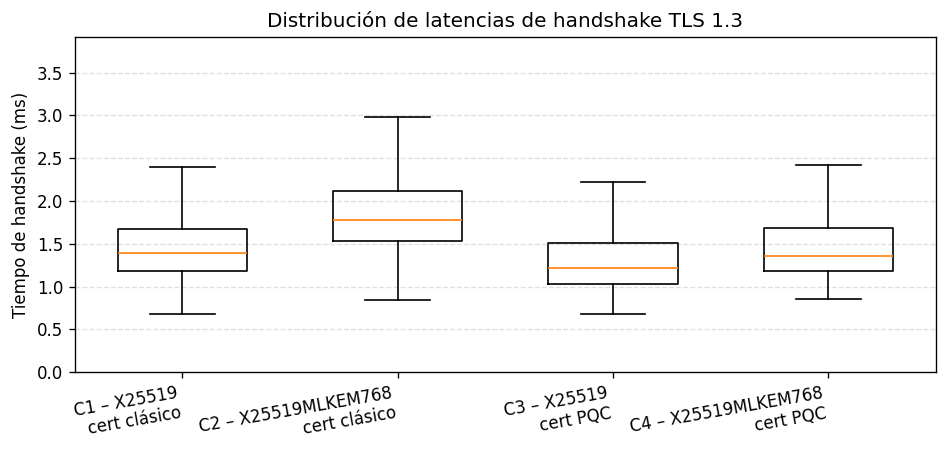

In [26]:
# 1. Boxplot de latencias

all_lat = np.concatenate([vals for vals in latency_values.values()])

p_low, p_high = np.quantile(all_lat, [0.001, 0.995])

y_min = 0.0
y_max = float(p_high * 1.05)

fig, ax = plt.subplots(figsize=(8, 4))

scenario_keys = list(SCENARIOS.keys())

labels = [
    SCENARIOS[k]["label"].replace(", ", "\n")
    for k in scenario_keys
]

data = [latency_values[k] for k in scenario_keys]

bp = ax.boxplot(
    data,
    labels=labels,
    showfliers=False,
    widths=0.6,
)

ax.set_ylabel("Tiempo de handshake (ms)")
ax.set_title("Distribución de latencias de handshake TLS 1.3")

plt.setp(ax.get_xticklabels(), rotation=10, ha="right")

ax.set_ylim(y_min, y_max)

ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.tight_layout()

boxplot_path = RESULTS_DIR / "latency_boxplot.png"
fig.savefig(boxplot_path, bbox_inches="tight")
print(f"Figura guardada en: {boxplot_path}")

plt.show()

Figura guardada en: results/latency_cdf.png


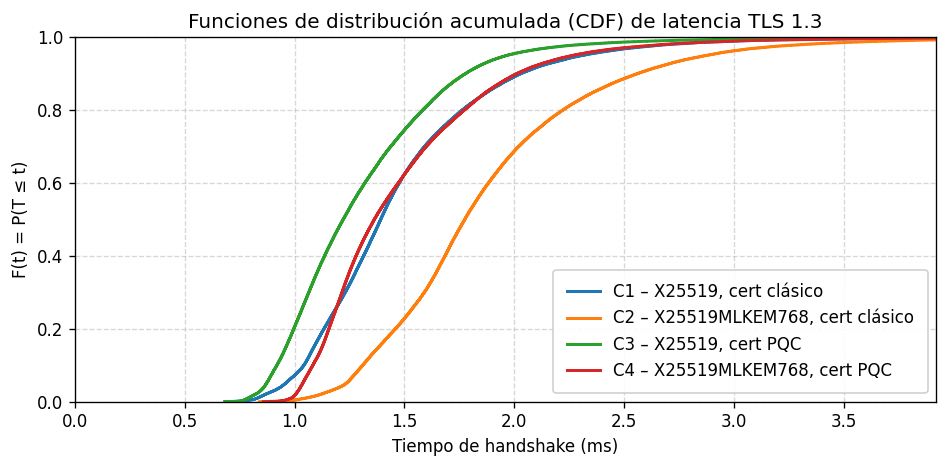

In [27]:
# 2. CDF de latencias

all_lat = np.concatenate([vals for vals in latency_values.values()])
p_low, p_high = np.quantile(all_lat, [0.001, 0.995])

x_min = 0.0
x_max = float(p_high * 1.05)

fig, ax = plt.subplots(figsize=(8, 4))

scenario_keys = list(SCENARIOS.keys())

for key in scenario_keys:
    label = SCENARIOS[key]["label"]
    lat = np.sort(latency_values[key])
    n = len(lat)
    if n == 0:
        continue
    y = np.arange(1, n + 1) / n

    ax.plot(
        lat,
        y,
        linewidth=1.8,
        label=label,
    )

ax.set_xlabel("Tiempo de handshake (ms)")
ax.set_ylabel("F(t) = P(T \u2264 t)")
ax.set_title("Funciones de distribución acumulada (CDF) de latencia TLS 1.3")

ax.set_xlim(x_min, x_max)
ax.set_ylim(0.0, 1.0)

ax.grid(True, linestyle="--", alpha=0.5)

legend = ax.legend(
    loc="lower right",
    frameon=True,
    framealpha=0.9,
    borderpad=0.8,
)

fig.tight_layout()

cdf_path = RESULTS_DIR / "latency_cdf.png"
fig.savefig(cdf_path, bbox_inches="tight")
print(f"Figura guardada en: {cdf_path}")

plt.show()

Figura guardada en: results/cpu_time_per_handshake_bar.png


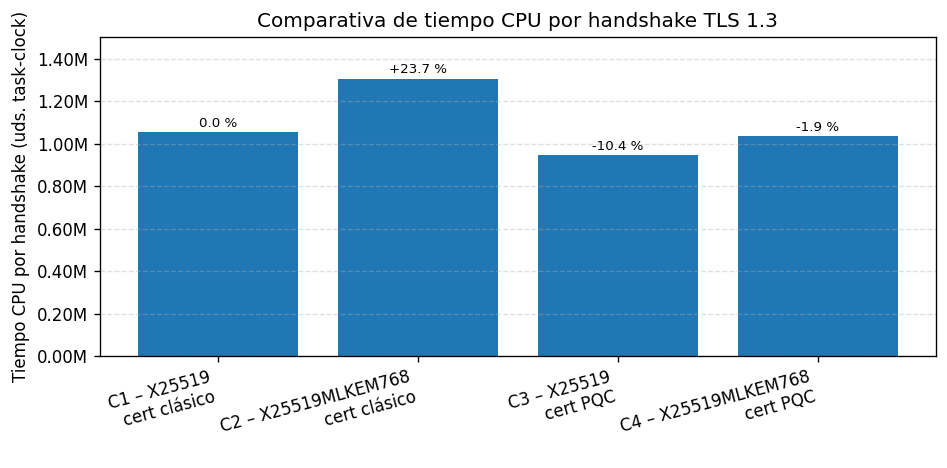

In [29]:
# 3. Tiempo de CPU por handshake (task-clock)

from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(8, 4))

scenario_keys = list(SCENARIOS.keys())
x_positions = np.arange(len(scenario_keys))
labels = [SCENARIOS[k]["label"].replace(", ", "\n") for k in scenario_keys]

cpu_per_hs = cpu_df.loc[scenario_keys, "task_clock_per_hs"].to_numpy()

# Baseline: C1
base_idx = scenario_keys.index(BASELINE_SCENARIO)
base_cpu = cpu_per_hs[base_idx]

# Overheads (en % respecto a C1)
overheads_pct = 100.0 * (cpu_per_hs - base_cpu) / base_cpu

bars = ax.bar(x_positions, cpu_per_hs)

ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=15, ha="right")

def millions_formatter(v, pos):
    return f"{v/1e6:.2f}M"

ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))

ax.set_ylabel("Tiempo CPU por handshake (uds. task-clock)")
ax.set_title("Comparativa de tiempo CPU por handshake TLS 1.3")

y_min = 0.0
y_max = cpu_per_hs.max() * 1.15
ax.set_ylim(y_min, y_max)

ax.grid(axis="y", linestyle="--", alpha=0.4)

for i, (x, val, ov) in enumerate(zip(x_positions, cpu_per_hs, overheads_pct)):
    if i == base_idx:
        text = "0.0 %"
    else:
        text = f"{ov:+.1f} %"
    ax.text(
        x,
        val * 1.01,
        text,
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.tight_layout()

cpu_bar_path = RESULTS_DIR / "cpu_time_per_handshake_bar.png"
fig.savefig(cpu_bar_path, bbox_inches="tight")
print(f"Figura guardada en: {cpu_bar_path}")

plt.show()

In [31]:
size_df["handshake_bytes_mean"] = (
    size_df["bytes_read_mean"] + size_df["bytes_written_mean"]
)

# OJO no exactamente correcta sin covarianza!!!
size_df["handshake_bytes_std_approx"] = np.sqrt(
    size_df["bytes_read_std"]**2 + size_df["bytes_written_std"]**2
)

handshake_size_table = size_df[[
    "label",
    "bytes_read_mean",
    "bytes_written_mean",
    "handshake_bytes_mean",
    "handshake_bytes_std_approx",
]]

handshake_size_table = handshake_size_table.loc[list(SCENARIOS.keys())]

print("\nTabla 3 – Tamaño medio de handshake por escenario (bytes)")
display(handshake_size_table.round(1))

(handshake_size_table.round(1)
                     .to_csv(RESULTS_DIR / "summary_handshake_size_table.csv"))

try:
    handshake_size_table.round(1).to_latex(
        RESULTS_DIR / "summary_handshake_size_table.tex"
    )
except Exception as e:
    print(f"[AVISO] No se pudo exportar handshake_size_table a LaTeX: {e}")


Tabla 3 – Tamaño medio de handshake por escenario (bytes)


,label,bytes_read_mean,bytes_written_mean,handshake_bytes_mean,handshake_bytes_std_approx
scenario,,,,,
c1_classic,"C1 – X25519, cert clásico",1318.0,402.0,1720.0,0.7
c2_hybrid_classiccert,"C2 – X25519MLKEM768, cert clásico",2406.0,1578.0,3984.0,0.7
c3_classic_pqcert,"C3 – X25519, cert PQC",14787.0,398.0,15185.0,0.0
c4_hybrid_pqcert,"C4 – X25519MLKEM768, cert PQC",15875.0,1574.0,17449.0,0.0


Figura guardada en: results/handshake_size_bar.png


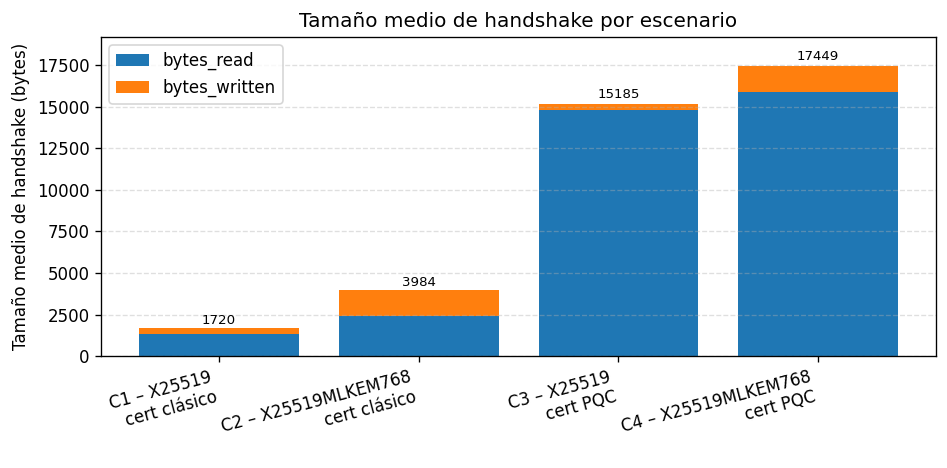

In [32]:
# 3. Tamaño de handshake por escenario (bytes)

fig, ax = plt.subplots(figsize=(8, 4))

scenario_keys = list(SCENARIOS.keys())
x_positions = np.arange(len(scenario_keys))
labels = [SCENARIOS[k]["label"].replace(", ", "\n") for k in scenario_keys]

bytes_read_mean = handshake_size_table.loc[scenario_keys, "bytes_read_mean"].to_numpy()
bytes_written_mean = handshake_size_table.loc[scenario_keys, "bytes_written_mean"].to_numpy()

bars_read = ax.bar(x_positions, bytes_read_mean, label="bytes_read")
bars_written = ax.bar(
    x_positions,
    bytes_written_mean,
    bottom=bytes_read_mean,
    label="bytes_written",
)

ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=15, ha="right")

ax.set_ylabel("Tamaño medio de handshake (bytes)")
ax.set_title("Tamaño medio de handshake por escenario")

y_max = (bytes_read_mean + bytes_written_mean).max() * 1.1
ax.set_ylim(0, y_max)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend()

handshake_totals = bytes_read_mean + bytes_written_mean
for x, total in zip(x_positions, handshake_totals):
    ax.text(
        x,
        total * 1.01,
        f"{total:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.tight_layout()

handshake_size_plot_path = RESULTS_DIR / "handshake_size_bar.png"
fig.savefig(handshake_size_plot_path, bbox_inches="tight")
print(f"Figura guardada en: {handshake_size_plot_path}")

plt.show()

In [33]:
CERTS_DIR = ".." / ROOT / "certs"

cert_files = {
    "ca_classic.crt": CERTS_DIR / "ca_classic.crt",
    "ca_pqc.crt": CERTS_DIR / "ca_pqc.crt",
    "server_classic.crt": CERTS_DIR / "server_classic.crt",
    "server_pqc.crt": CERTS_DIR / "server_pqc.crt",
    "server_classic.key": CERTS_DIR / "server_classic.key",
    "server_pqc.key": CERTS_DIR / "server_pqc.key",
    "ca_classic.key": CERTS_DIR / "ca_classic.key",
    "ca_pqc.key": CERTS_DIR / "ca_pqc.key",
}

In [35]:
cert_size_rows = []

for name, path in cert_files.items():
    if not path.is_file():
        print(f"[AVISO] No se encuentra {path}, se omite.")
        continue
    size_bytes = path.stat().st_size
    cert_size_rows.append(
        {
            "file": name,
            "size_bytes": size_bytes,
            "size_kib": size_bytes / 1024.0,
        }
    )

cert_sizes_df = pd.DataFrame(cert_size_rows)
cert_sizes_df = cert_sizes_df.sort_values("file").reset_index(drop=True)

print("\nTabla 4 – Tamaños de certificados y claves (bytes / KiB)")
display(cert_sizes_df.round({"size_kib": 2}))

(cert_sizes_df.round({"size_kib": 2})
             .to_csv(RESULTS_DIR / "summary_cert_sizes.csv", index=False))

try:
    cert_sizes_df.round({"size_kib": 2}).to_latex(
        RESULTS_DIR / "summary_cert_sizes.tex",
        index=False,
    )
except Exception as e:
    print(f"[AVISO] No se pudo exportar cert_sizes_df a LaTeX: {e}")


Tabla 4 – Tamaños de certificados y claves (bytes / KiB)


,file,size_bytes,size_kib
0,ca_classic.crt,591,0.58
1,ca_classic.key,302,0.29
2,ca_pqc.crt,7521,7.34
3,ca_pqc.key,8196,8.00
4,server_classic.crt,570,0.56
5,server_classic.key,302,0.29
6,server_pqc.crt,7497,7.32
7,server_pqc.key,8196,8.00


Figura guardada en: results/cert_sizes_bar.png


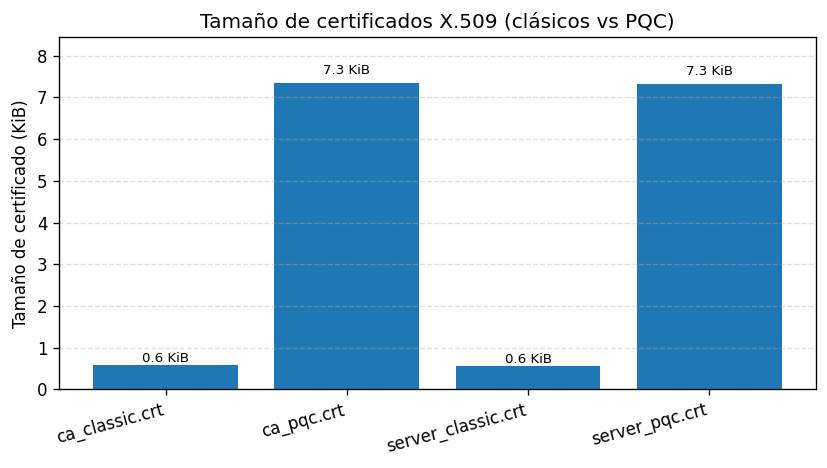

In [36]:
# 4.Tamaños de certificados (clásico vs PQC)

# Nos quedamos sólo con los .crt de servidor y CA
mask_crt = cert_sizes_df["file"].str.endswith(".crt")
crt_df = cert_sizes_df[mask_crt].copy()

fig, ax = plt.subplots(figsize=(7, 4))

x_positions = np.arange(len(crt_df))
labels = crt_df["file"].tolist()
sizes_kib = crt_df["size_kib"].to_numpy()

bars = ax.bar(x_positions, sizes_kib)

ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=15, ha="right")

ax.set_ylabel("Tamaño de certificado (KiB)")
ax.set_title("Tamaño de certificados X.509 (clásicos vs PQC)")

ax.set_ylim(0, sizes_kib.max() * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.4)

for x, val in zip(x_positions, sizes_kib):
    ax.text(
        x,
        val * 1.02,
        f"{val:.1f} KiB",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.tight_layout()

cert_sizes_plot_path = RESULTS_DIR / "cert_sizes_bar.png"
fig.savefig(cert_sizes_plot_path, bbox_inches="tight")
print(f"Figura guardada en: {cert_sizes_plot_path}")

plt.show()